# Image Preprocessing

## Import Libraries

In [15]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

## Set Dataset Path

In [16]:
input_folder = "../Clean_Dataset"
output_folder = "../Preprocessed_Dataset"

os.makedirs(output_folder, exist_ok=True)

print("Input :", input_folder)
print("Output:", output_folder)

Input : ../Clean_Dataset
Output: ../Preprocessed_Dataset


## Load Dataset

In [17]:
classes = [
    folder for folder in os.listdir(input_folder)
    if os.path.isdir(os.path.join(input_folder, folder))
]

print(classes)

['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [18]:
images = []

for cls in classes:

    class_path = os.path.join(input_folder, cls)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in files:
        images.append((cls, file))

print("Total Images:", len(images))

Total Images: 693


## Preprocessing

In [22]:
## Preprocessing

for cls, file in images:

    img_path = os.path.join(input_folder, cls, file)

    img = cv2.imread(img_path)

    if img is None:
        continue
    
    # Colour Normalisation
    img = cv2.normalize(
        img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Contrast Enhancement 
    lab = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge(
        (l,a,b)
    )

    img = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2BGR
    )

    # Save Preprocessed Image
    save_folder = os.path.join(
        output_folder,
        cls
    )

    os.makedirs(
        save_folder,
        exist_ok=True
    )

    save_path = os.path.join(
        save_folder,
        file
    )

    cv2.imwrite(
        save_path,
        img
    )

print("Image Preprocessing Completed!")

Image Preprocessing Completed!


## Display Before & After

Missing_hole
09_missing_hole_02.jpg
../Preprocessed_Dataset\Missing_hole\09_missing_hole_02.jpg
True


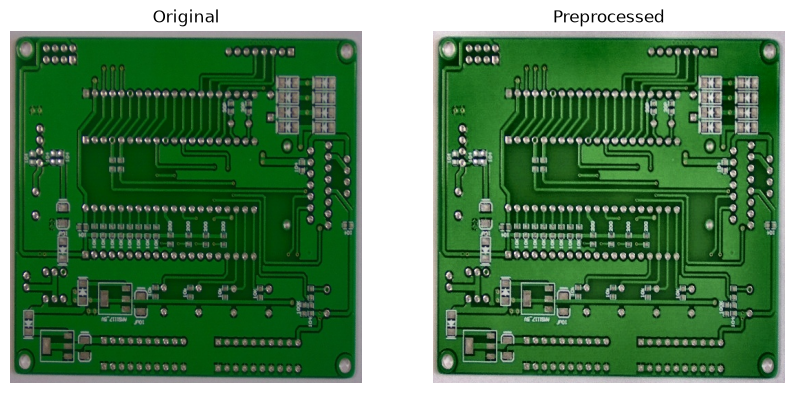

In [23]:
sample_class = random.choice(classes)

sample_folder = os.path.join(input_folder, sample_class)

sample_file = random.choice([
    f for f in os.listdir(sample_folder)
    if f.lower().endswith((".jpg",".jpeg",".png"))
])

# debug
print(sample_class)
print(sample_file)

print(os.path.join(output_folder, sample_class, sample_file))

print(os.path.exists(
    os.path.join(output_folder, sample_class, sample_file)
))

original = cv2.imread(os.path.join(input_folder, sample_class, sample_file))
processed = cv2.imread(os.path.join(output_folder, sample_class, sample_file))

original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)



plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Preprocessed")
plt.axis("off")

plt.show()

## Summary

In [21]:
processed_images = 0

print("========== Preprocessed Dataset Summary ==========")

for cls in classes:

    folder = os.path.join(output_folder, cls)

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    processed_images += count

    print(f"{cls}: {count}")

print("-------------------------------------")
print("Processed Images:", processed_images)

========== Preprocessed Dataset Summary ==========
Missing_hole: 115
Mouse_bite: 115
Open_circuit: 116
Short: 116
Spur: 115
Spurious_copper: 116
-------------------------------------
Processed Images: 693
